In [1]:
from sklearn.model_selection import train_test_split
from imblearn.ensemble import BalancedRandomForestClassifier

In [ ]:
filename = 'raw'

In [2]:
train_path = f'data/descriptors_df_train_{filename}.pkl'

In [3]:
import pandas as pd 
train_df = pd.read_pickle(train_path)

# Fill NaNs
train_df.fillna(train_df.mean(), inplace=True)

# Prepare features and targets
feature_cols = [col for col in train_df.columns 
                if col not in ['graph_id', 'edge_source', 'edge_dest', 'is_causal']]

X_train = train_df[feature_cols]
y_train = train_df['is_causal']

clf = BalancedRandomForestClassifier(n_estimators=500,random_state=42)
clf.fit(X_train, y_train)

/home/gpaldino/miniconda3/envs/td2c/lib/python3.8/site-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/home/gpaldino/miniconda3/envs/td2c/lib/python3.8/site-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
/home/gpaldino/miniconda3/envs/td2c/lib/python3.8/site-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this

BalancedRandomForestClassifier(n_estimators=500, random_state=42)

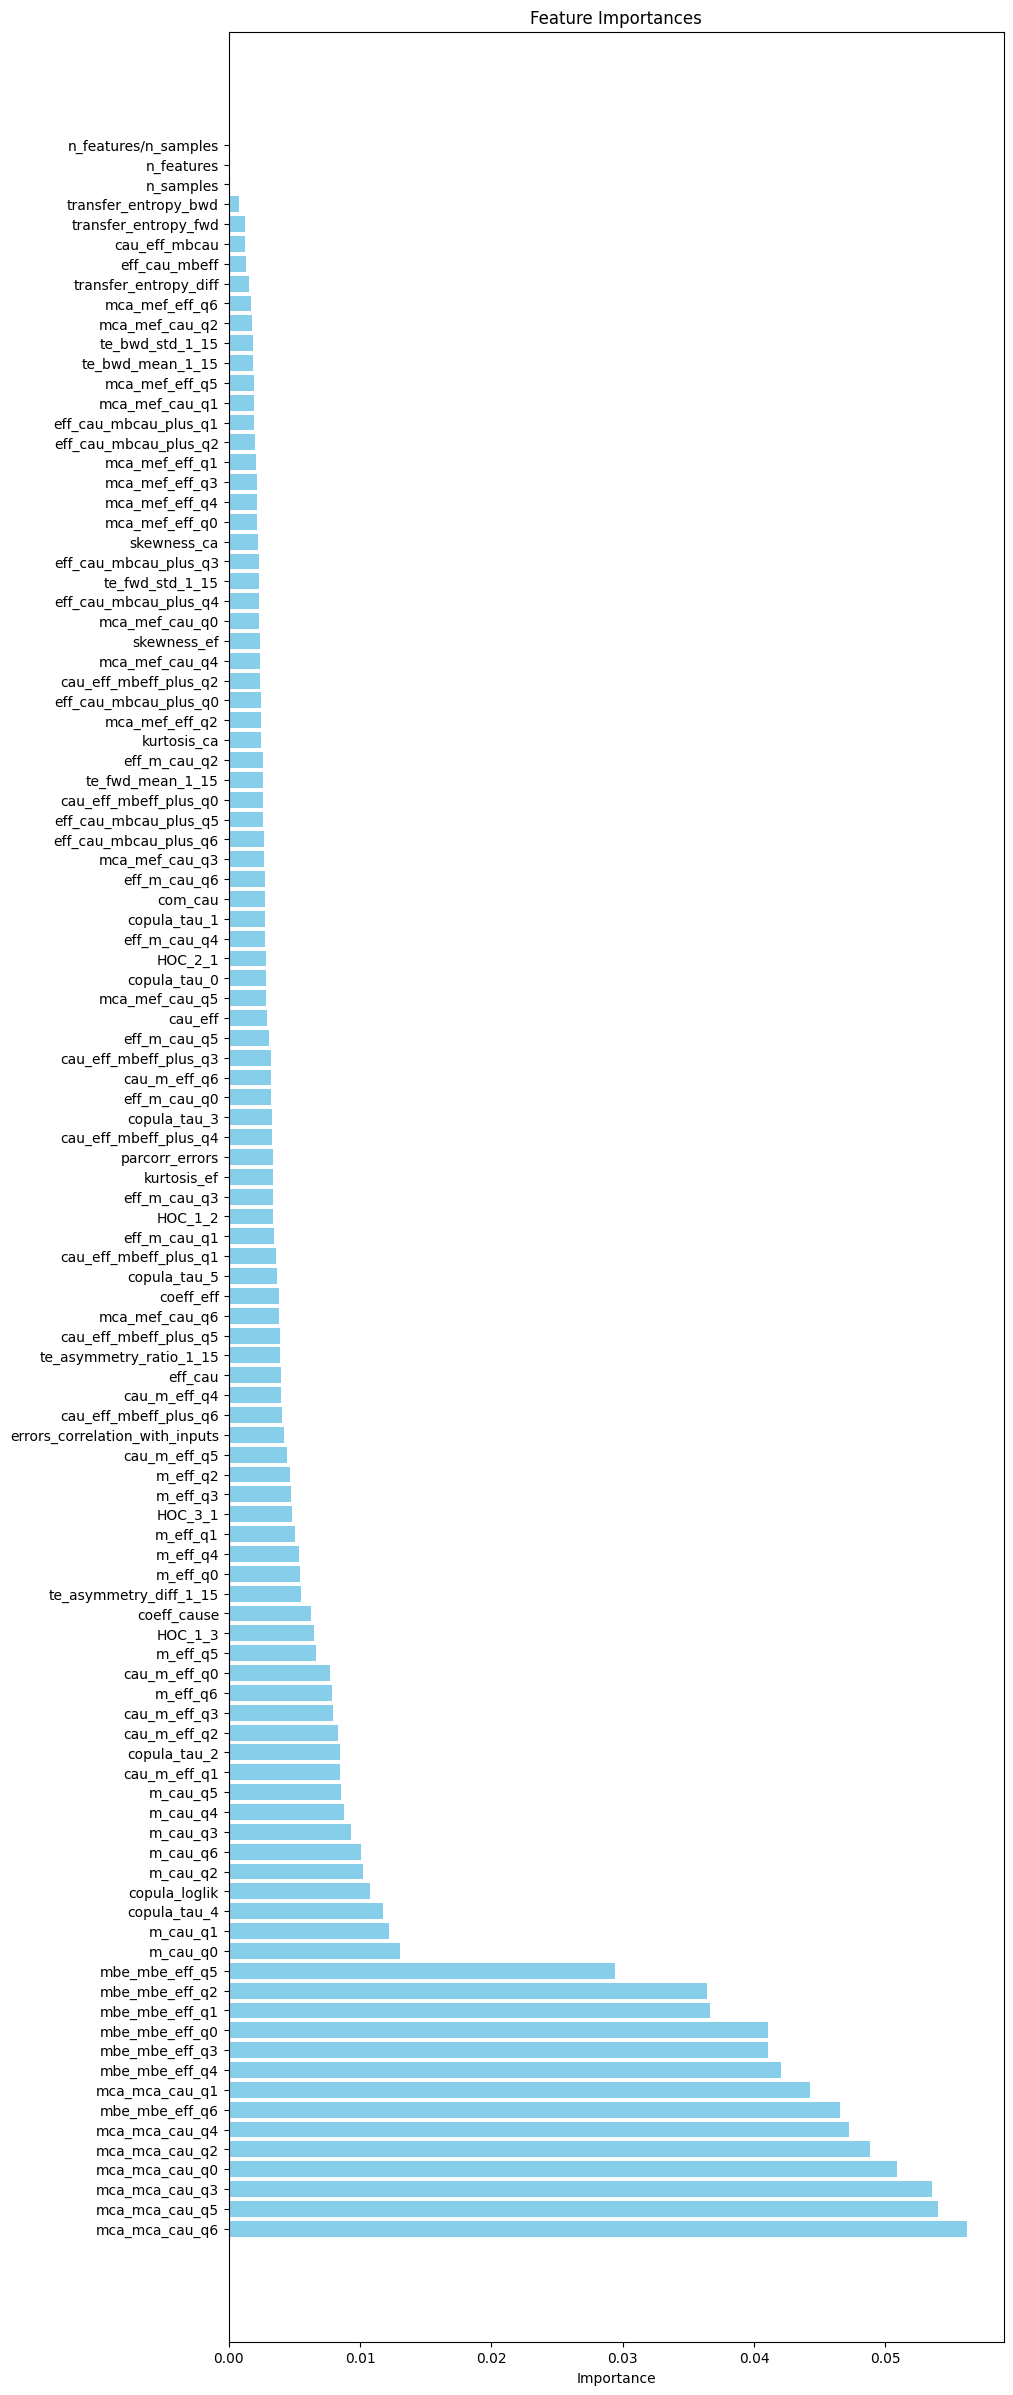

In [4]:
import matplotlib.pyplot as plt

# Get feature importances
importances = clf.feature_importances_

# Create a DataFrame for visualization
feature_importances = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})

# Sort the DataFrame by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 30))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.show()


In [5]:
feature_importances.to_csv('feature_importances.csv', index=False)

In [6]:
filtered_features = feature_importances[feature_importances['Feature'].str.contains('ard')]
filtered_features


,Feature,Importance


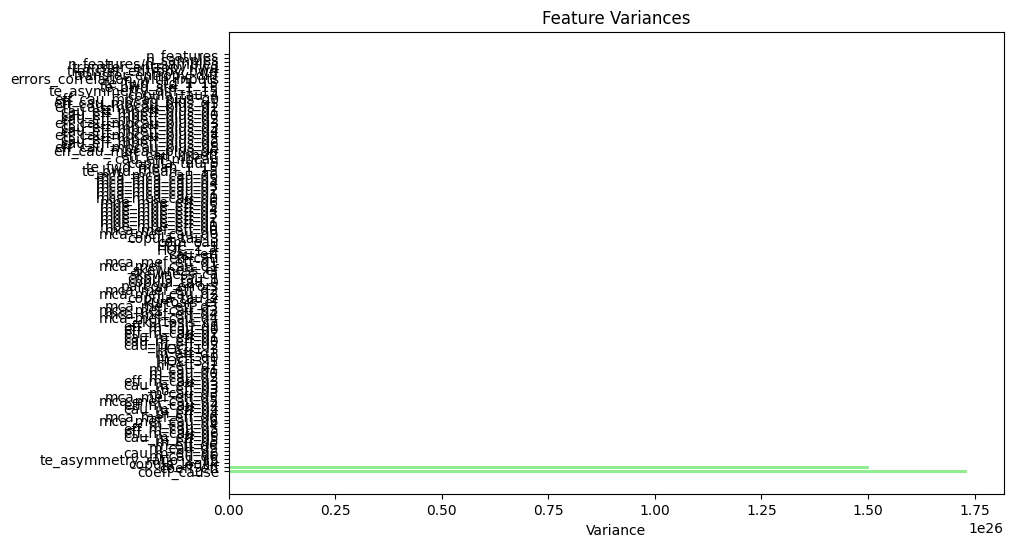

In [7]:
variances = X_train.var()
sorted_features = variances.sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(sorted_features.index, sorted_features.values, color='lightgreen')
plt.xlabel('Variance')
plt.title('Feature Variances')
plt.show()


In [8]:
sorted_features

coeff_cause                1.731800e+26
coeff_eff                  1.503132e+26
copula_loglik              5.117078e+05
te_asymmetry_ratio_1_15    4.365639e+02
m_cau_q6                   2.400679e+00
                               ...     
transfer_entropy_bwd       8.980024e-04
transfer_entropy_fwd       8.456037e-04
n_features/n_samples       3.160060e-29
n_samples                  0.000000e+00
n_features                 0.000000e+00
Length: 106, dtype: float64

In [9]:
sorted_features[3:-3].to_csv('feature_variances.csv', header=False)

In [10]:
filtered_features = sorted_features[sorted_features.index.str.contains('asy')]
filtered_features


te_asymmetry_ratio_1_15    436.563887
te_asymmetry_diff_1_15       0.004743
dtype: float64